# Nama: wirdana
# NIM: 4222301031
# Kelas: B_pagi


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [2]:
df = pd.read_csv('WineQT.csv')

## EDA

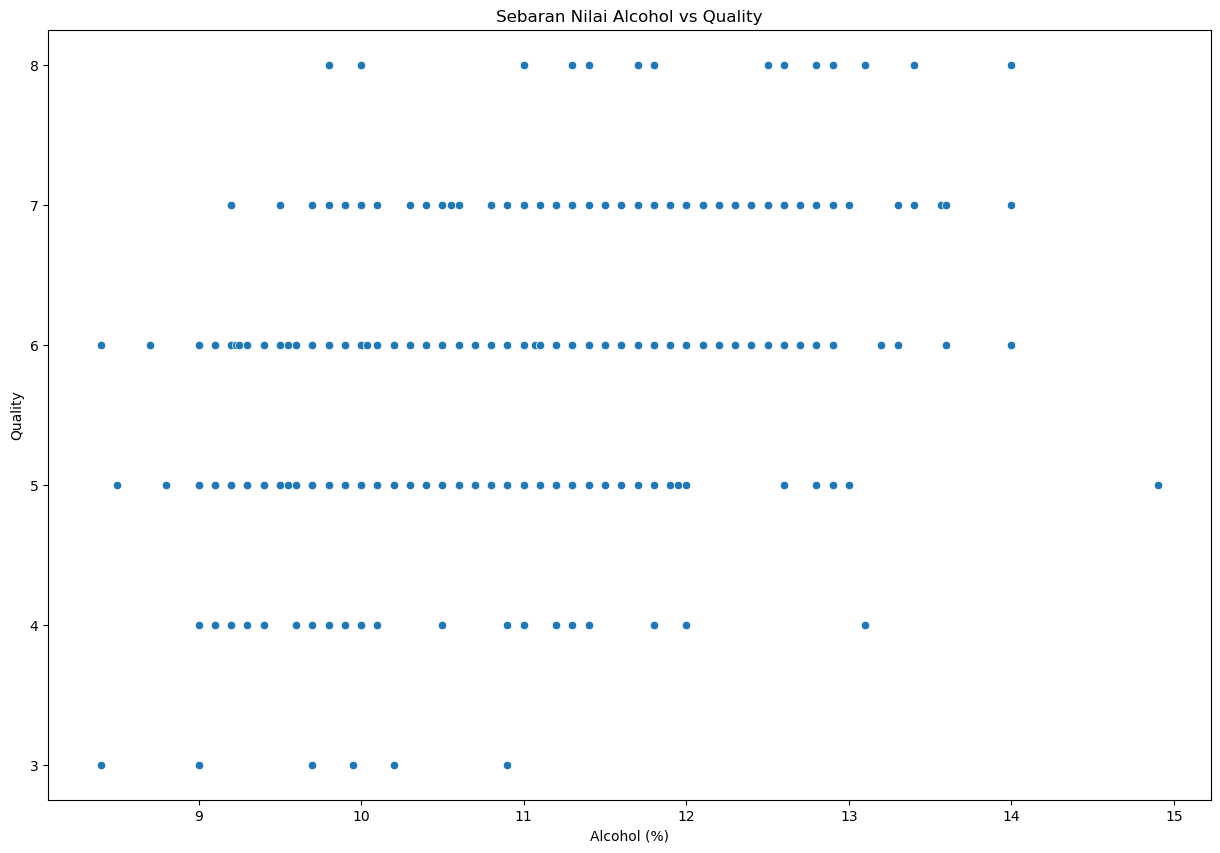

In [3]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Sebaran Nilai Alcohol vs Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.show()

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


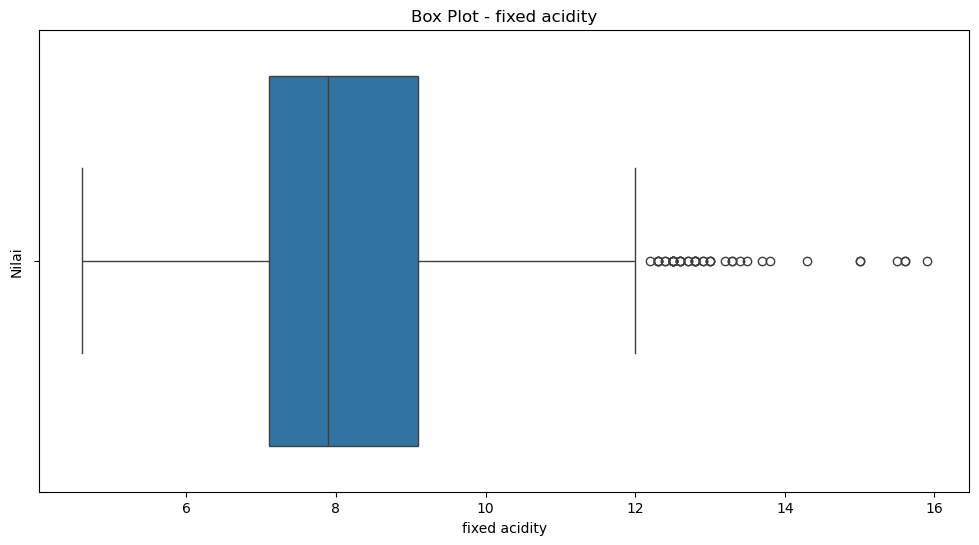

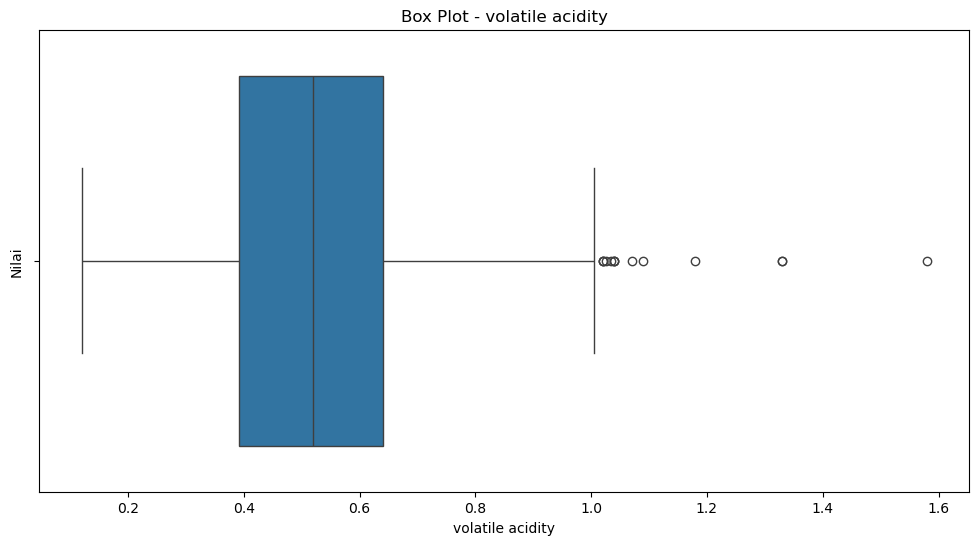

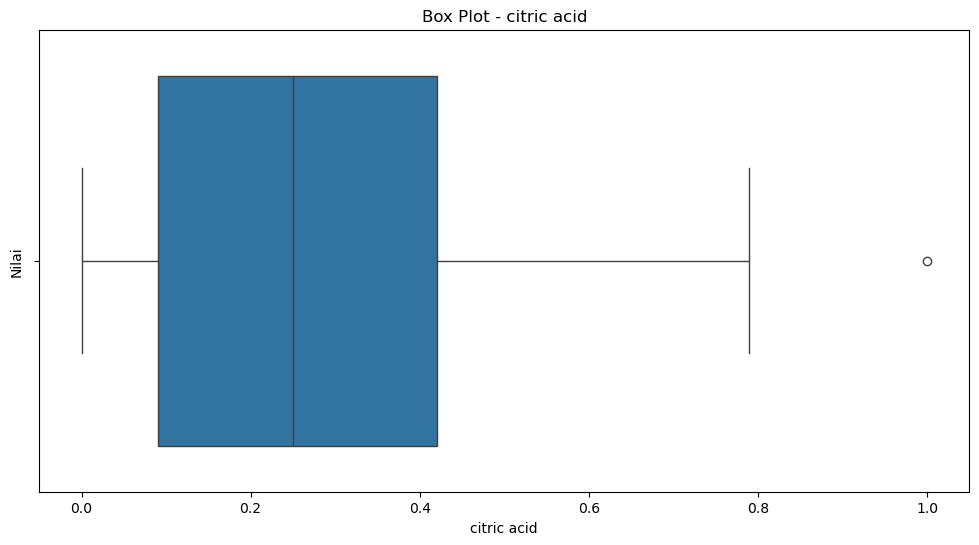

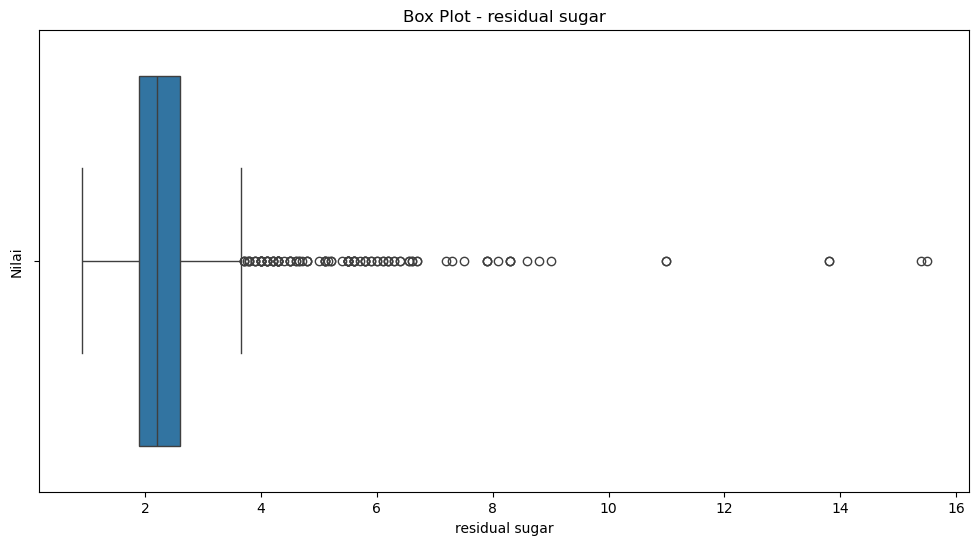

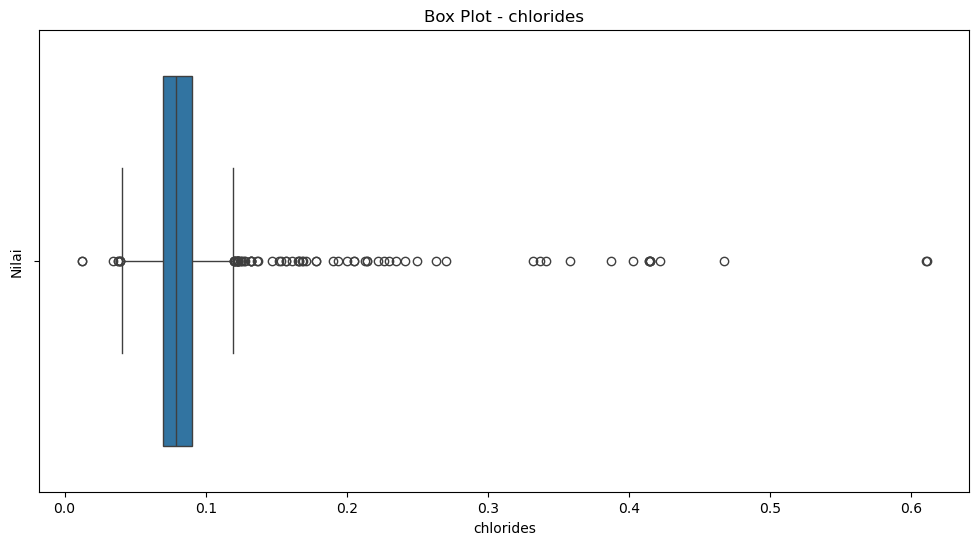

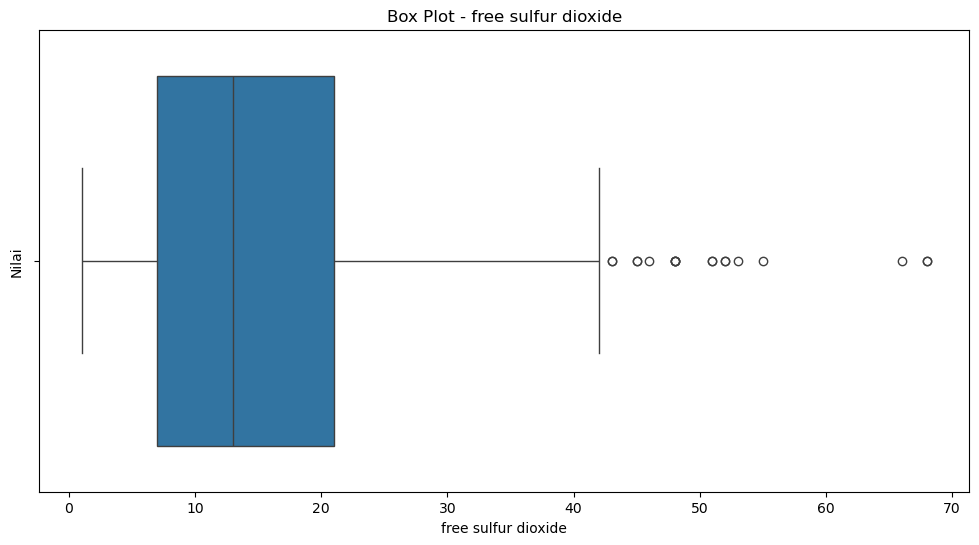

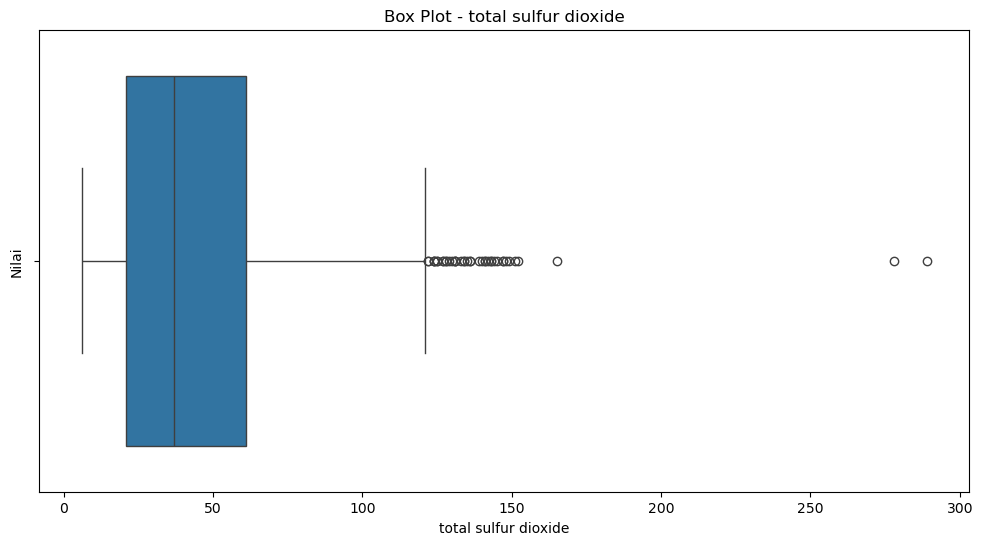

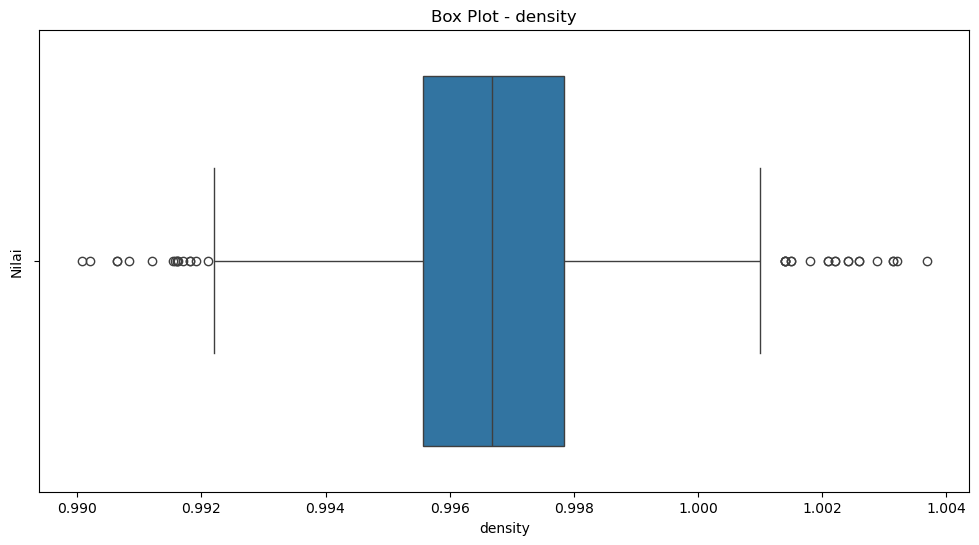

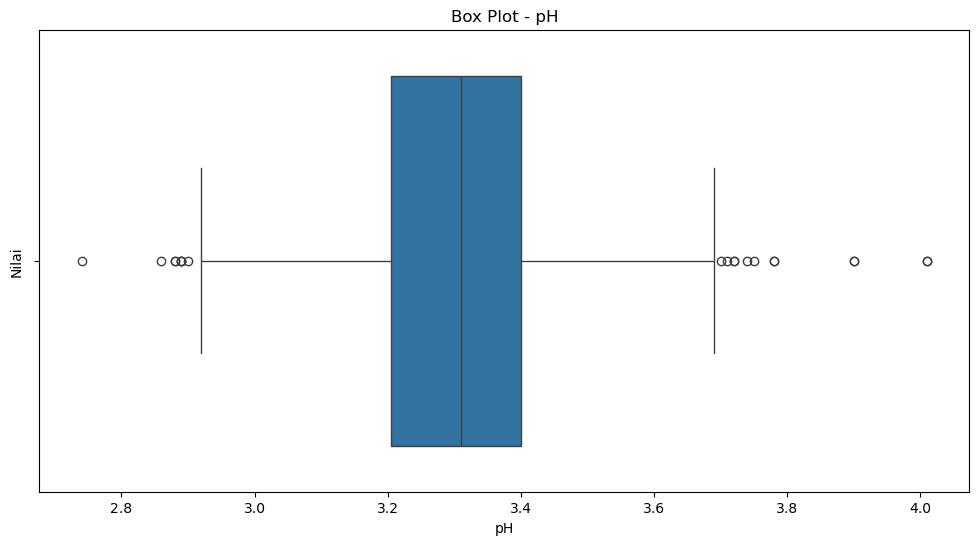

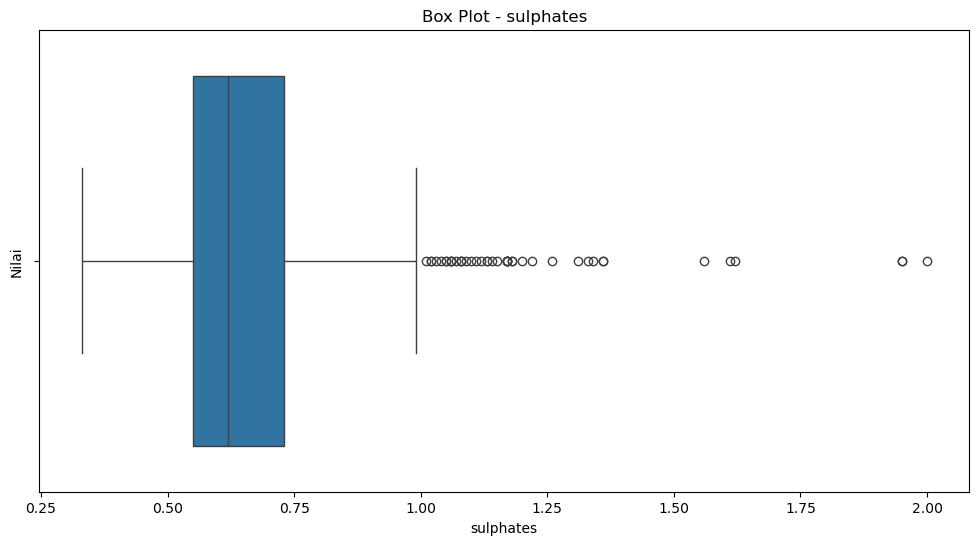

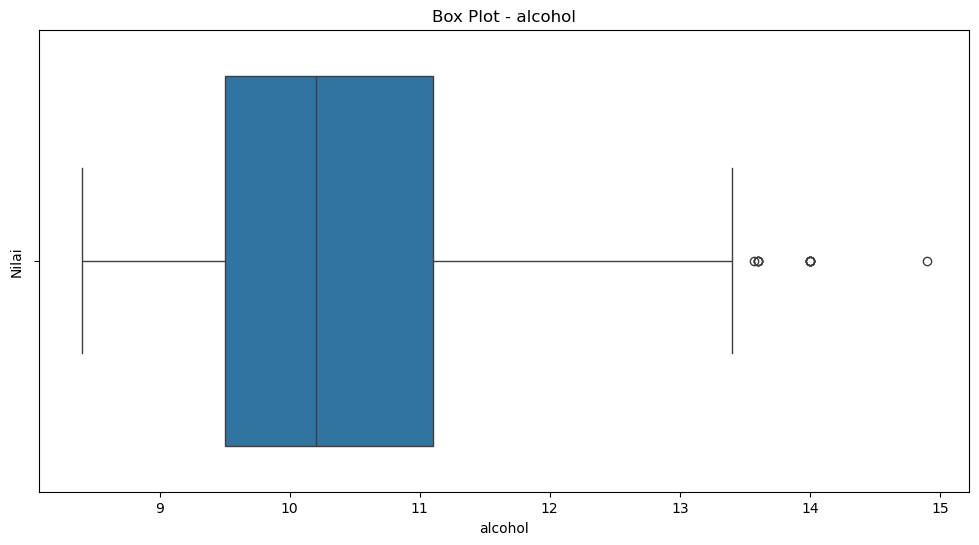

In [5]:
# Looping untuk kolom fitur utama
columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
           'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
           'density', 'pH', 'sulphates', 'alcohol']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

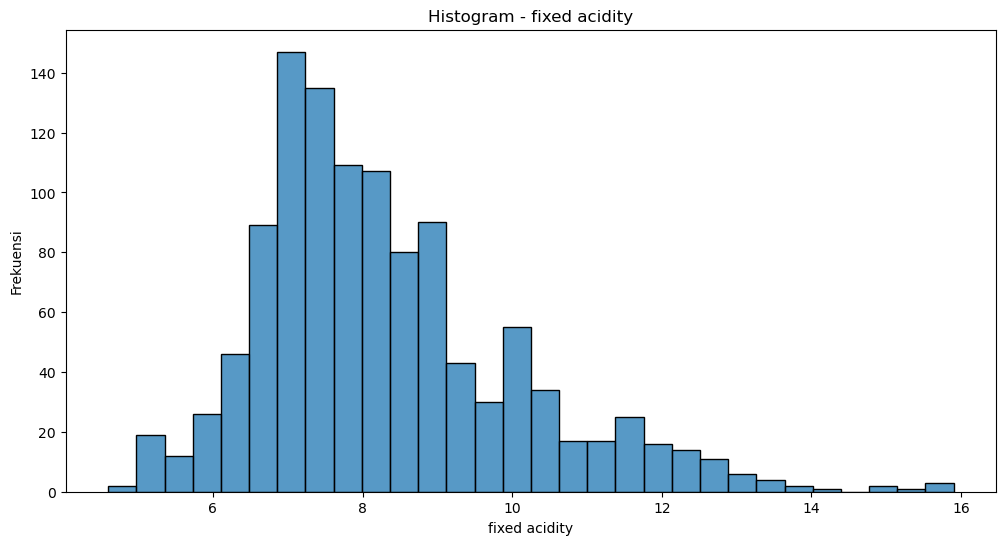

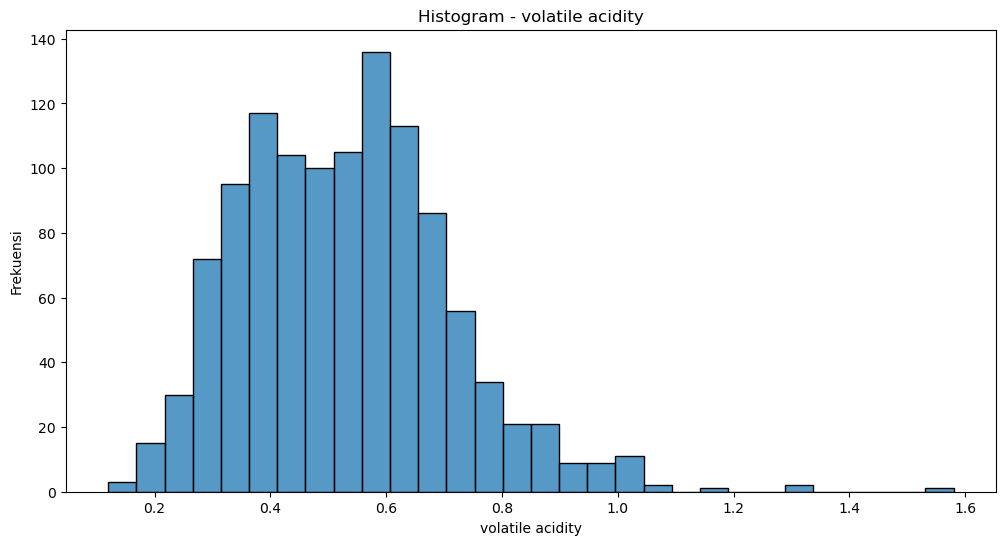

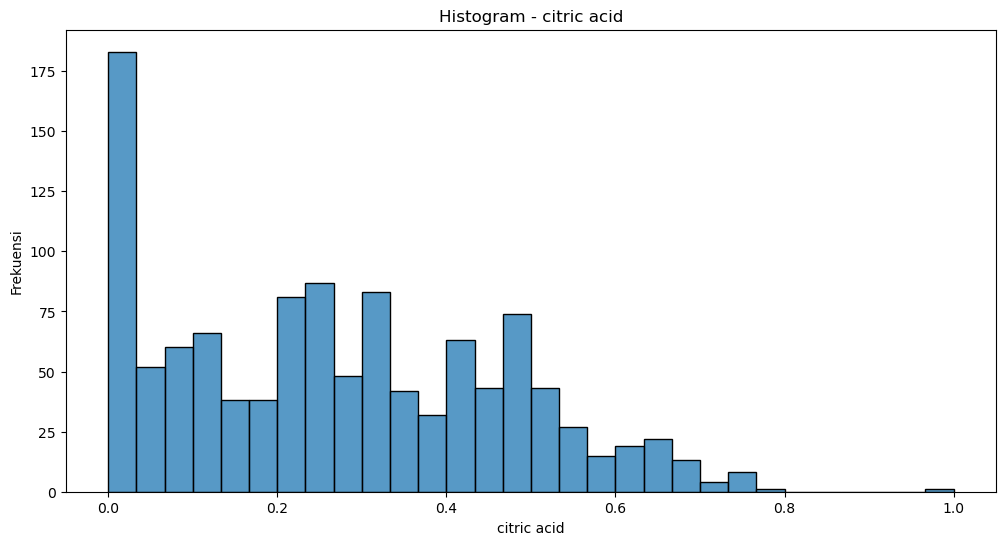

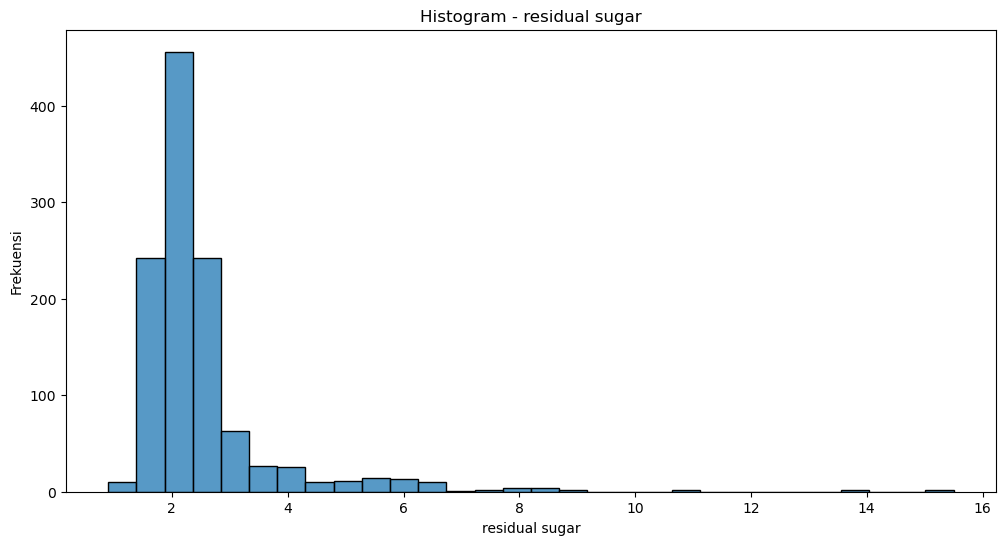

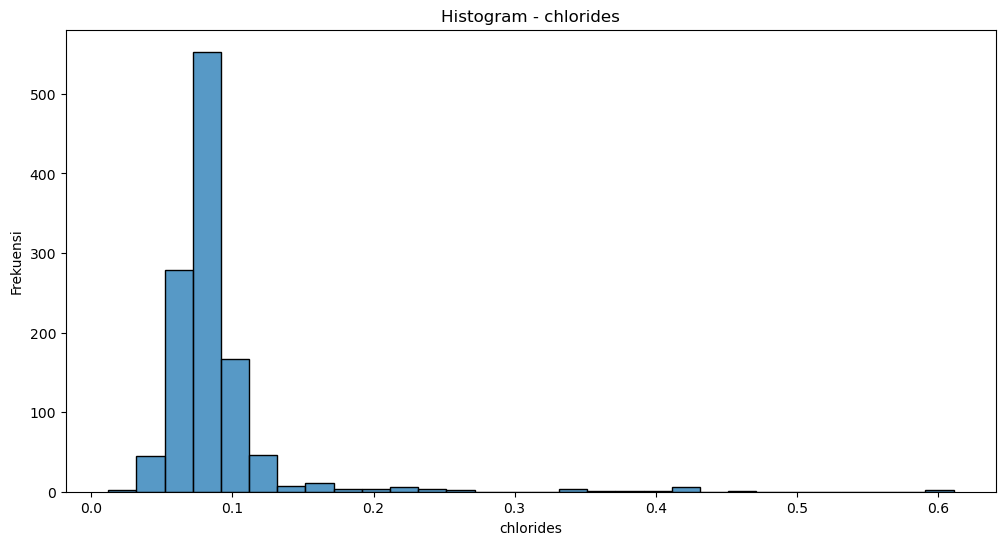

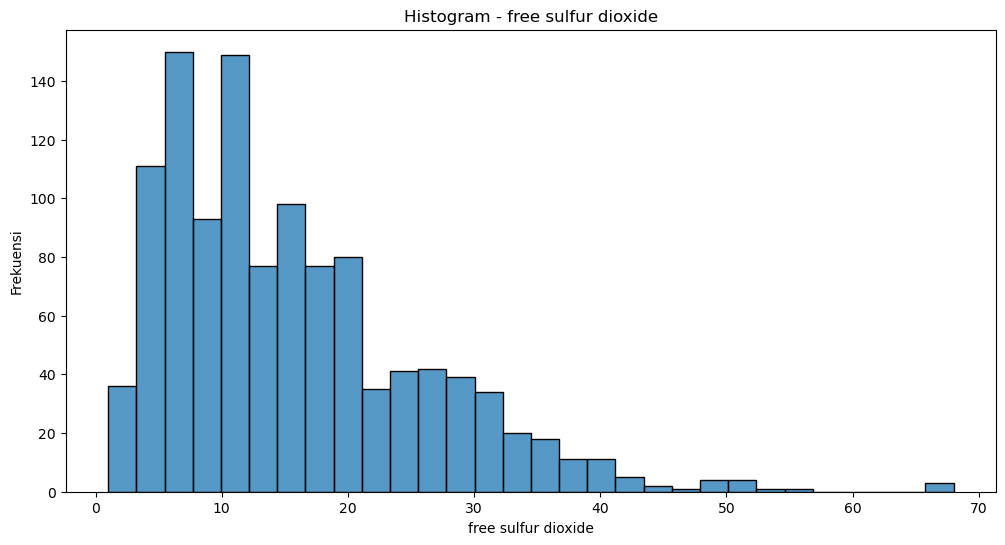

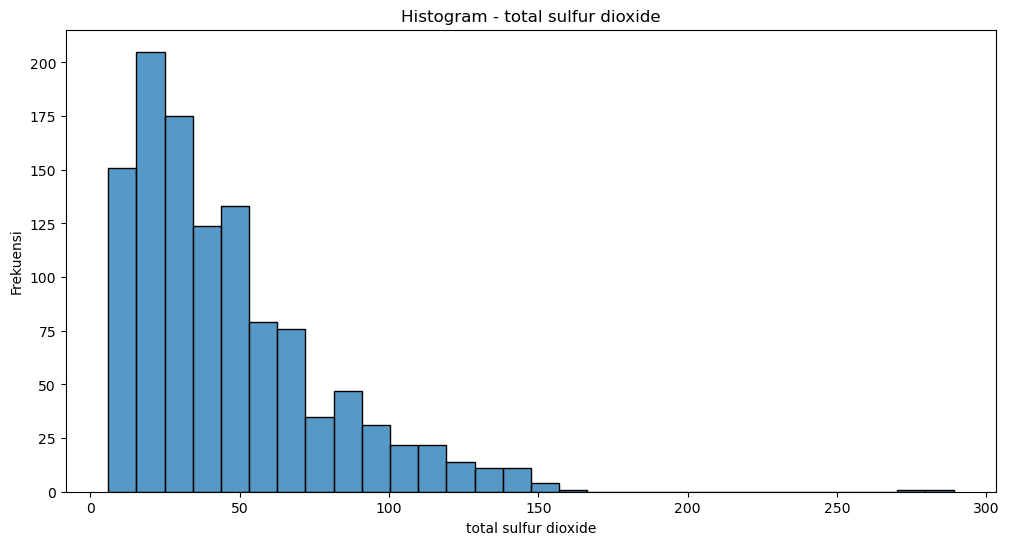

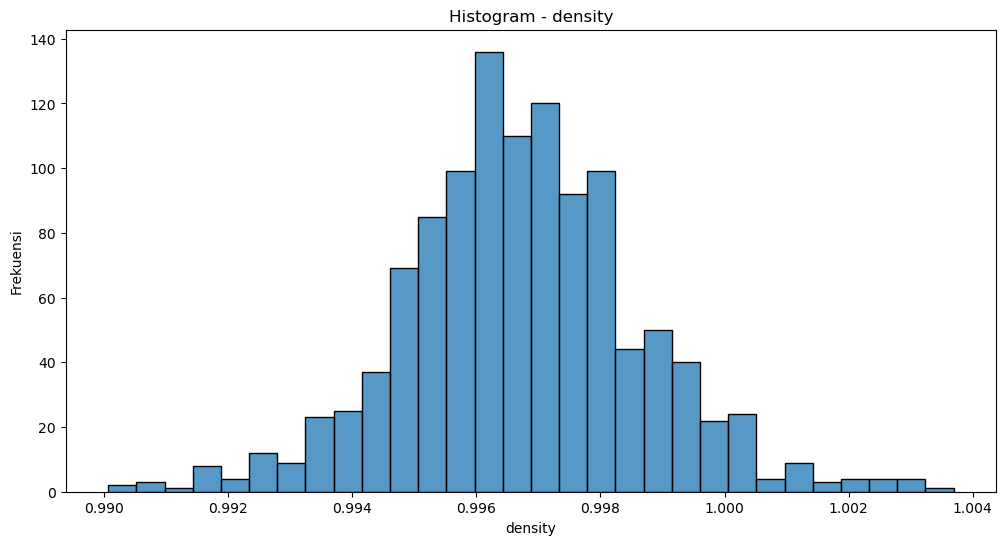

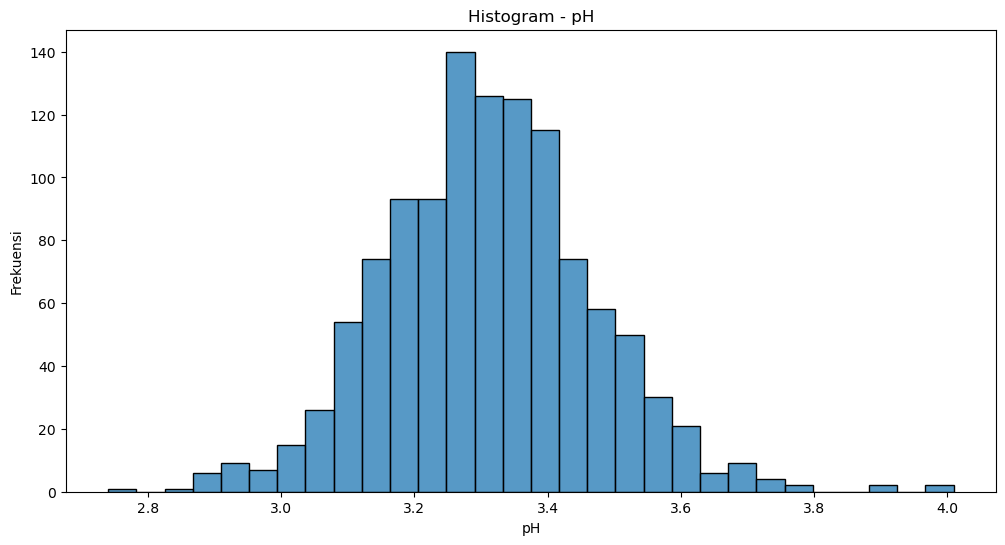

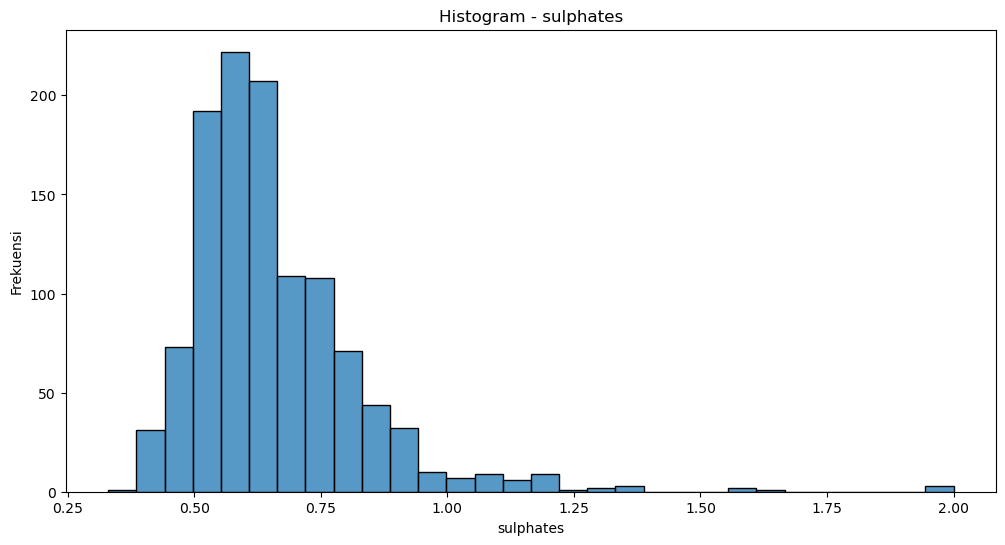

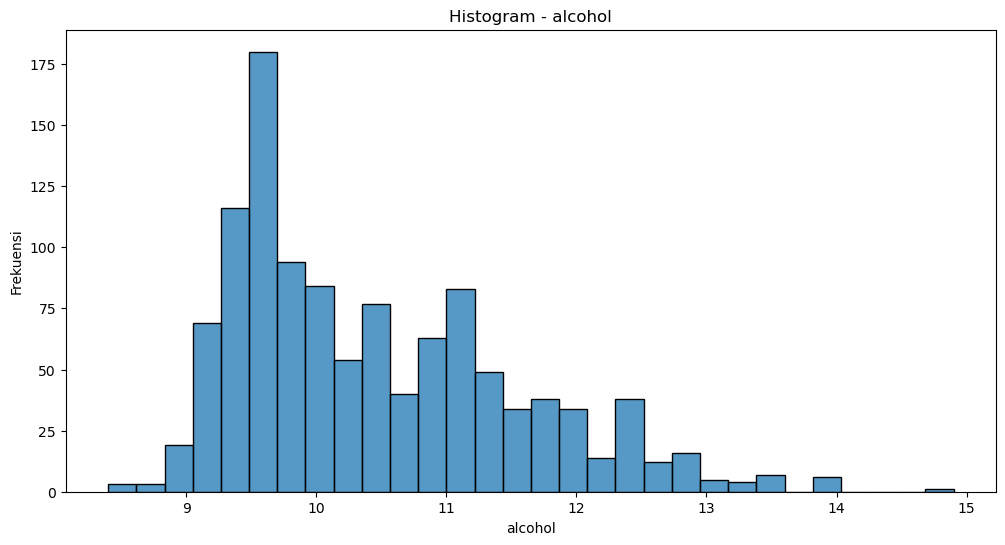

In [6]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional) -> Pada dataset WineQT, beberapa outlier mungkin ada namun masih dalam rentang nilai yang masuk akal secara kimia, sehingga tidak dihapus
3. Feature Scaling

In [26]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yang duplikat (atau cetak jumlah yang dihapus)

In [27]:
# Pilih fitur untuk clustering (drop kolom Id dan quality sebagai label referensi)
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']

X = df[fitur_columns].values
y = df['quality'].values  # label referensi (anotator)

In [9]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data=X_std, columns=fitur_columns)
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [10]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]])

In [11]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scaling menggunakan Standard Scaler

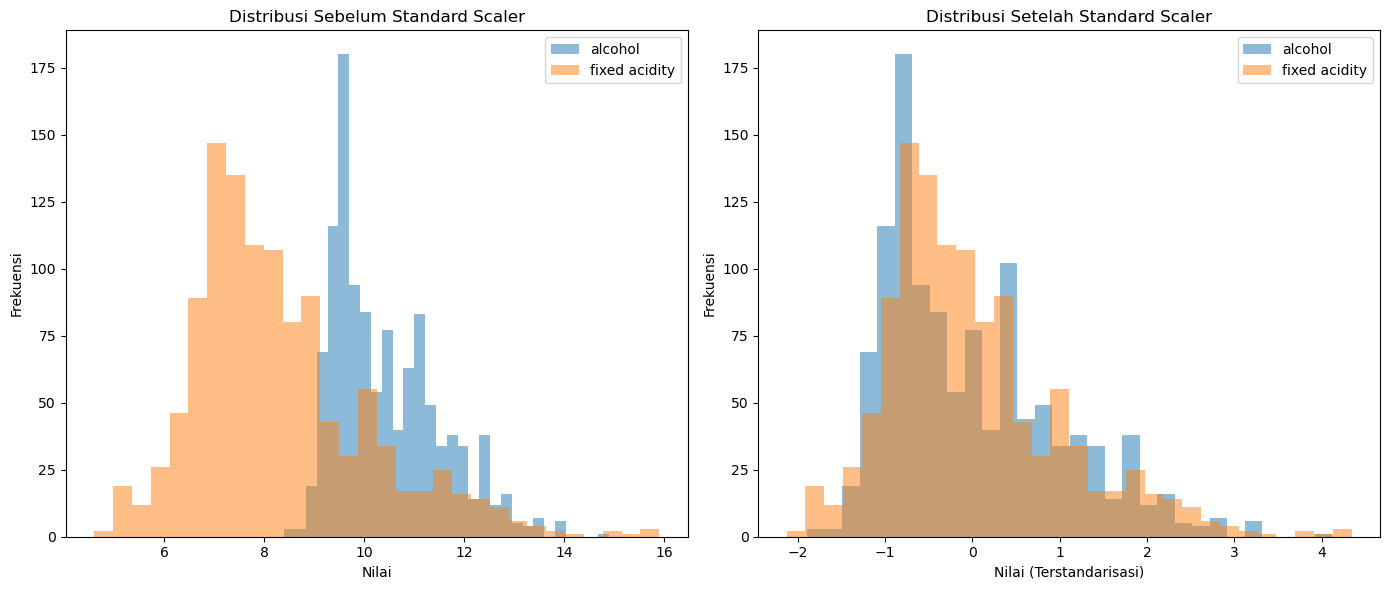

In [12]:
# Cek grafik sebelum dan setelah scaling
# Kita lihat distribusi dari variabel sebelum Standard Scaler dan setelah Standard Scaler
# Gunakan fitur 'alcohol' dan 'fixed acidity' sebagai contoh representatif

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

# Plot distribusi sebelum Standard Scaler (Isi dibawah ini)
for col in ['alcohol', 'fixed acidity']:
    ax1.hist(df[col], bins=30, alpha=0.5, label=col)
ax1.set_title('Distribusi Sebelum Standard Scaler')
ax1.set_xlabel('Nilai')
ax1.set_ylabel('Frekuensi')

# Plot distribusi setelah Standard Scaler (Isi dibawah ini)
for col in ['alcohol', 'fixed acidity']:
    ax2.hist(df_scalling[col], bins=30, alpha=0.5, label=col)
ax2.set_title('Distribusi Setelah Standard Scaler')
ax2.set_xlabel('Nilai (Terstandarisasi)')
ax2.set_ylabel('Frekuensi')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Penyelarasan Rentang Nilai (Scaling):
Sebelum dilakukan StandardScaler, variabel  dan  memiliki rentang nilai yang sangat berbeda (sumbu X di grafik kiri tidak sejajar). Setelah di-scale, kedua variabel kini memiliki rentang yang sama (sumbu X di grafik kanan berhimpit pada rentang sekitar -2 hingga +4), yang memudahkan algoritma machine learning untuk membandingkan keduanya secara objektif.alcoholfixed acidity

2. Penyamaan Pusat Data (Mean Centering):
Pada grafik kanan, terlihat bahwa kedua distribusi sekarang "berpusat" di sekitar angka 0 pada sumbu X. Hal ini menunjukkan bahwa proses StandardScaler telah berhasil melakukan mean centering, di mana rata-rata dari kedua fitur tersebut kini bernilai nol.

3. Standarisasi Penyebaran (Unit Variance):
Meskipun bentuk distribusi masing-masing fitur tetap sama (bentuk histogramnya tidak berubah), penyebaran data telah diseragamkan. Sekarang, kedua fitur memiliki standar deviasi 1. Hal ini sangat krusial bagi algoritma berbasis jarak (distance-based algorithms) seperti KNN, SVM, atau K-Means agar tidak ada fitur yang mendominasi hanya karena skala angkanya lebih besar.

4. Mempertahankan Informasi Distribusi:
Penting untuk dicatat bahwa StandardScaler tidak mengubah bentuk distribusi asli data Anda. Jika data asli miring ke kanan (skewed), maka setelah di-scale pun data akan tetap terlihat miring ke kanan. Ini adalah hal yang baik karena informasi atau karakteristik pola data yang asli tetap terjaga sepenuhnya.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label quality wine.
1. Metode Elbow
2. Via-Score Plot

### Metode Elbow

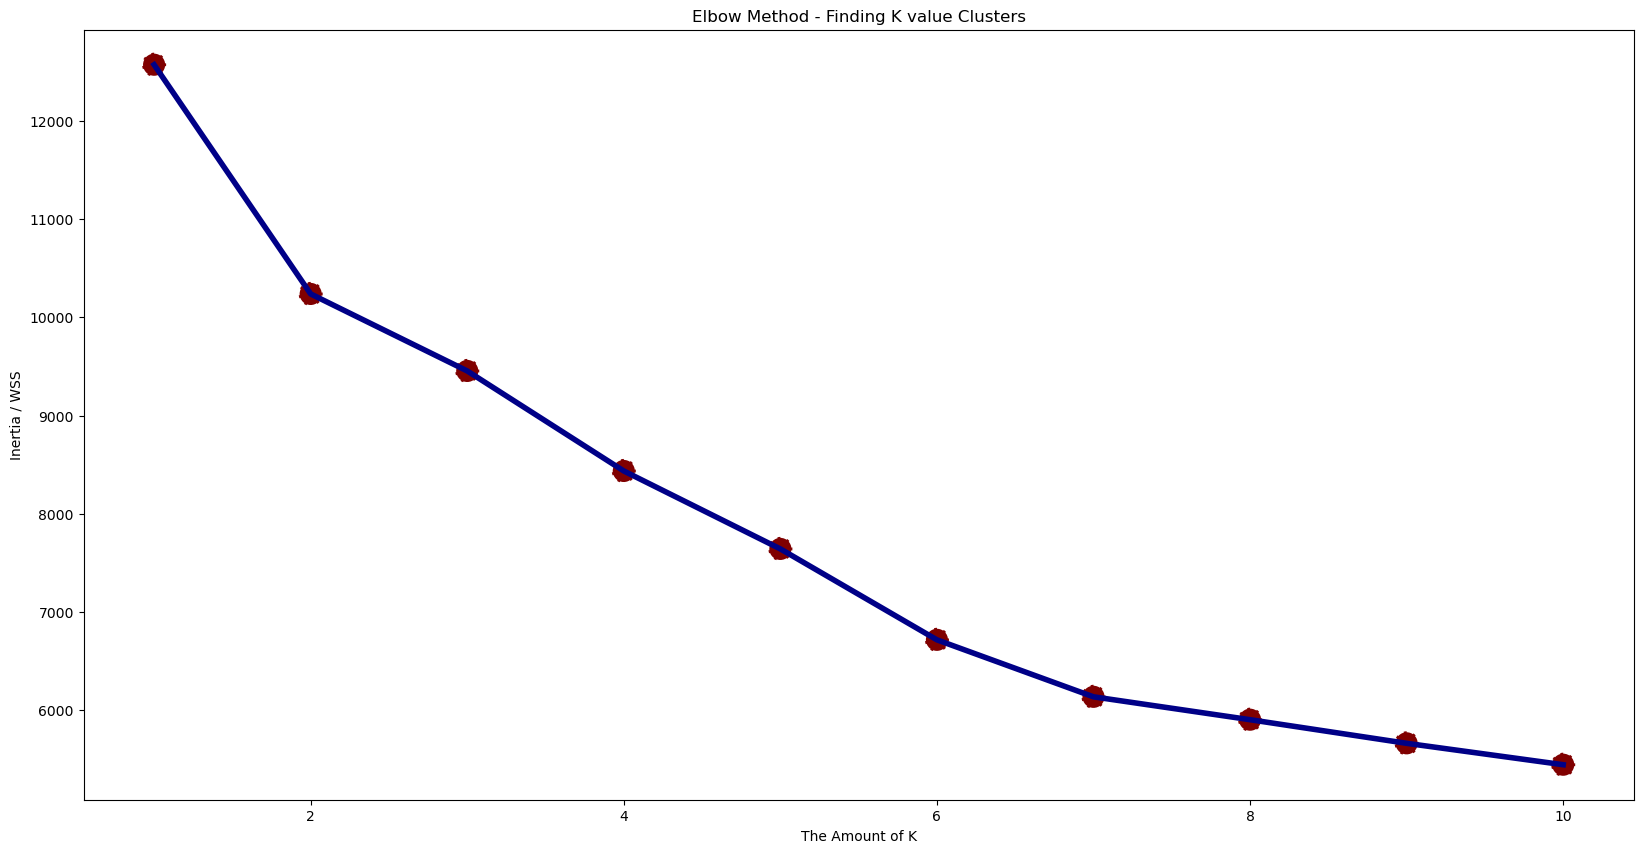

In [13]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000', linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Inertia / WSS')
plt.show()

In [14]:
# Dari hasil diatas elbow-nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [15]:
# Taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [16]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5,1
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6,1
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8,1
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10,1


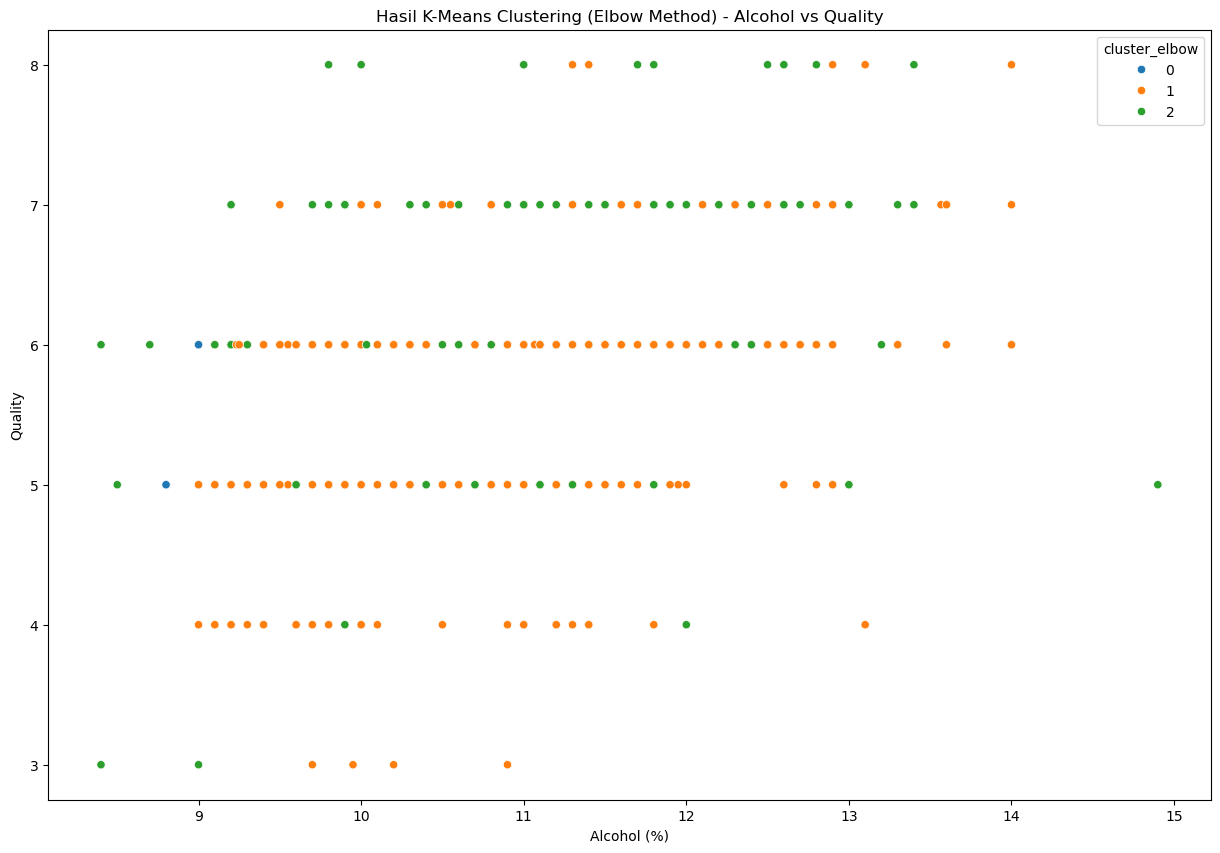

In [17]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_elbow', palette='tab10')
plt.title('Hasil K-Means Clustering (Elbow Method) - Alcohol vs Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.show()

### Bandingkan hasil dengan label quality (anotator)

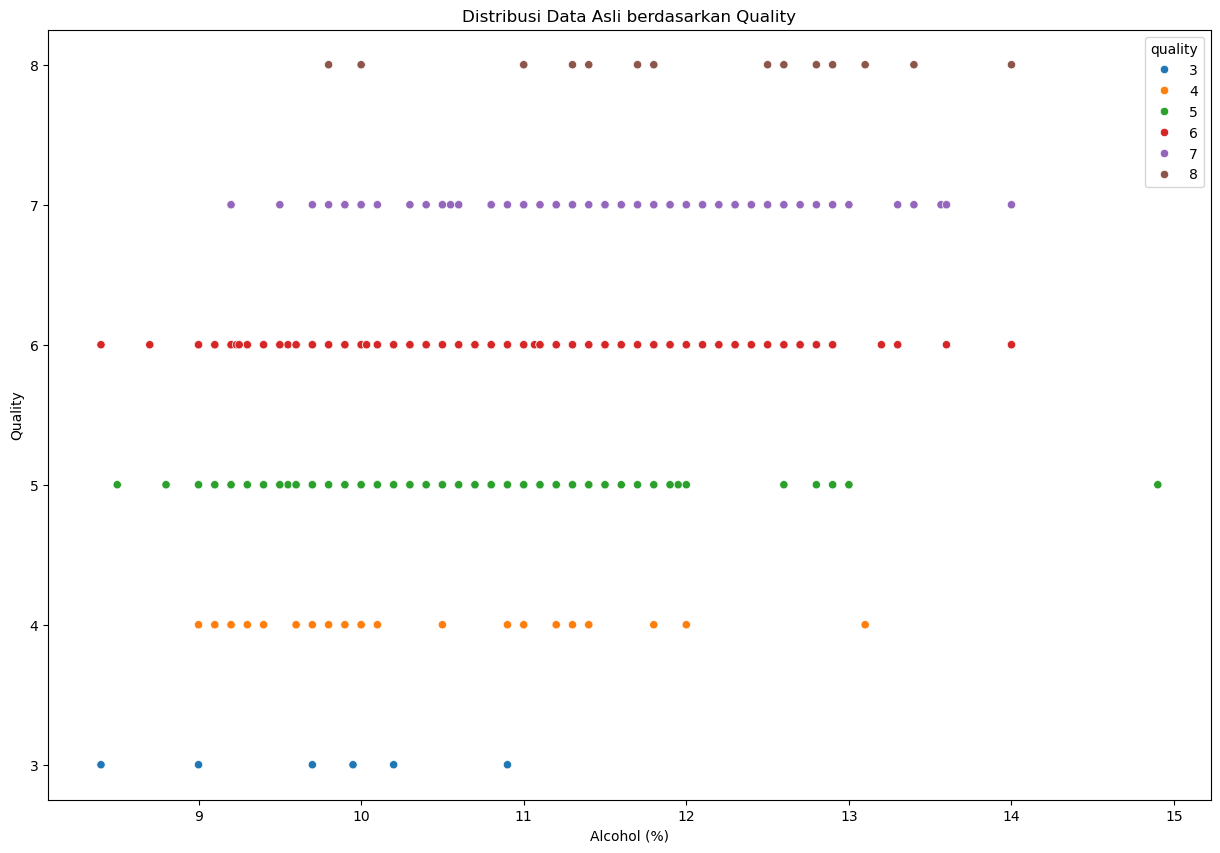

In [18]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='tab10')
plt.title('Distribusi Data Asli berdasarkan Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.show()

### Hasil diatas ketika menggunakan elbow ialah representatif, karena cluster dapat merepresentasikan kelompok kualitas wine. Dengan kondisi umum :
1. Cluster 0 -> Wine kualitas rendah (quality 3-4)
2. Cluster 1 -> Wine kualitas sedang (quality 5-6)
3. Cluster 2 -> Wine kualitas tinggi (quality 7-8)

### 2. Via Score Plot

In [19]:
!pip install yellowbrick

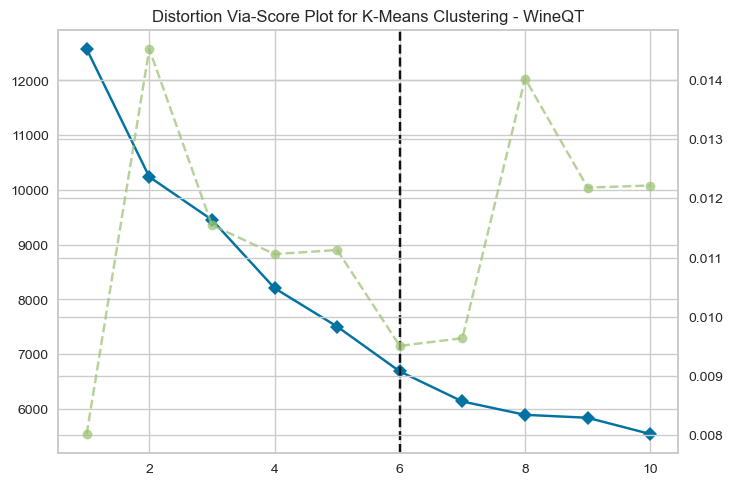

In [20]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k adalah rentang jumlah cluster
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True)
visualizer.fit(df_scalling.values)  # Fit data ke visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering - WineQT')
plt.show()

In [21]:
# Dari hasil diatas K-nya dipilih pada angka yang ditunjukkan oleh garis putus-putus visualizer,
# karena titik distorsinya bertemu pada nilai tersebut di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [22]:
# Taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [23]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,1,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,1,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,1,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,2,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,1,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5,1,1
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6,1,1
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7,1,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8,1,1
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10,1,1


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

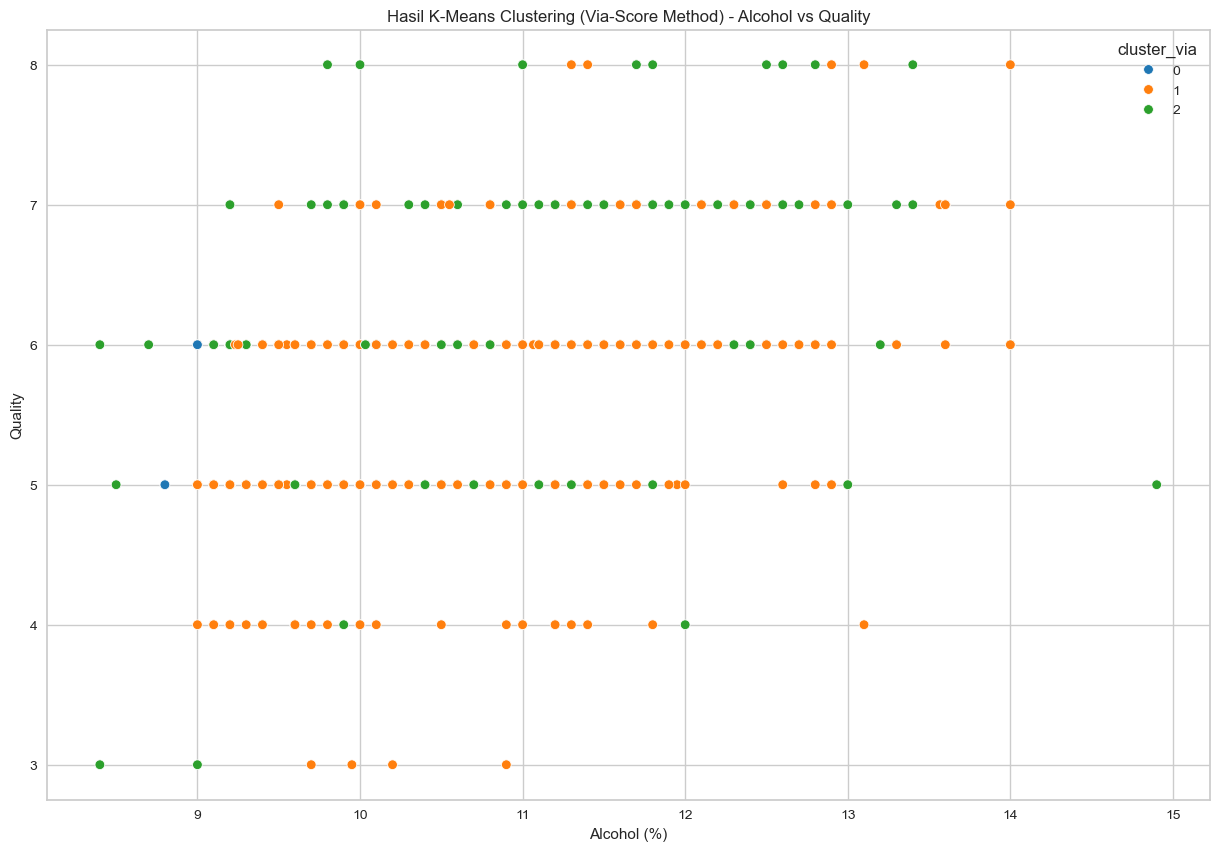

In [24]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_via', palette='tab10')
plt.title('Hasil K-Means Clustering (Via-Score Method) - Alcohol vs Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.show()

### Bandingkan dengan label quality (anotator)

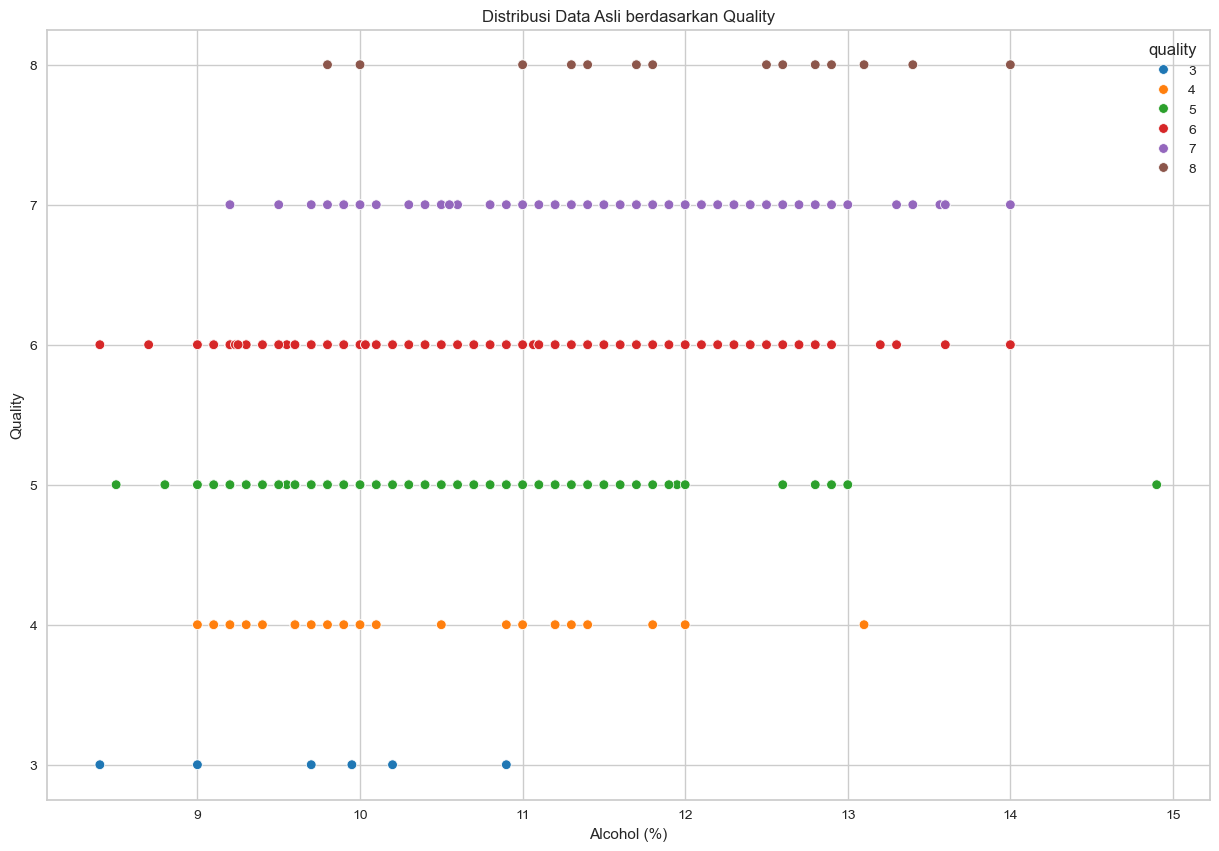

In [25]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='tab10')
plt.title('Distribusi Data Asli berdasarkan Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Kemampuan Algoritma dalam Menangkap Pola Data:
Dengan membandingkan kedua gambar tersebut, terlihat bahwa algoritma K-Means mencoba mengelompokkan data berdasarkan kedekatan nilai "Alcohol" dan "Quality". Namun, terlihat bahwa K-Means (yang hanya menggunakan 3 klaster: 0, 1, dan 2) tidak mampu mereplikasi label asli yang memiliki 6 kategori kualitas (3 sampai 8). Algoritma ini cenderung mencampur berbagai tingkat kualitas ke dalam satu klaster warna yang sama, yang menunjukkan bahwa fitur  saja mungkin belum cukup untuk memisahkan kualitas wine secara sempurna.alcohol

2. Keterbatasan Pemisahan Klaster (Overlap):
Pada grafik K-Means, terlihat banyak tumpang tindih (overlap) antar klaster (warna biru, oranye, dan hijau tersebar di hampir seluruh rentang kualitas). Hal ini mengindikasikan bahwa batas pemisah yang ditentukan oleh K-Means bersifat linear/geometris dan tidak menangkap karakteristik unik dari setiap level kualitas wine.

3. Korelasi Fitur vs. Klaster:
Grafik menunjukkan bahwa kualitas wine yang lebih tinggi (seperti kualitas 7 dan 8) cenderung berada pada kadar alkohol yang lebih tinggi. K-Means berhasil menangkap sebagian dari tren ini (klaster hijau banyak berada di area kualitas tinggi), tetapi tetap gagal melakukan klasifikasi yang presisi karena K-Means adalah teknik unsupervised learning yang tidak "tahu" label target yang sebenarnya, ia hanya mengelompokkan berdasarkan kesamaan nilai numerik.

### Thank you :)